In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, classification_report, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.inspection import permutation_importance

## Load data

In [4]:
df2 = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df2.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-1.085628,0,0,0,1,5,0,1,1,1,0,0,0,0,0,0
1,3,0.420314,0,1,0,1,5,0,1,1,1,0,0,0,0,0,0


### Train-test split

In [5]:
X = df2.drop(columns=['malnurished'])
y = df2['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

# Linear Discriminant Analysis (LDA)

### Simple model

In [7]:
# Fit LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [8]:
y_pred = lda.predict(X_test)
print(f'Classification Report: \n{classification_report(y_test, y_pred)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.74      0.76      0.75       707
           1       0.70      0.68      0.69       579

    accuracy                           0.72      1286
   macro avg       0.72      0.72      0.72      1286
weighted avg       0.72      0.72      0.72      1286




In [9]:
y_probas = lda.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.7509705011053626


## Hyperparameter Tuning

In [14]:
params = [
    {'solver': ['svd'], 'shrinkage': [None]},
    {'solver': ['lsqr', 'eigen'], 'shrinkage': ['auto', 0.1, 0.3, 0.5, 0.7, 0.9]}
]

lda_params = LinearDiscriminantAnalysis()
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=lda_params,
    param_grid=params,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 10 folds for each of 13 candidates, totalling 130 fits


,estimator,LinearDiscriminantAnalysis()
,param_grid,"[{'shrinkage': [None], 'solver': ['svd']}, {'shrinkage': ['auto', 0.1, ...], 'solver': ['lsqr', 'eigen']}]"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,solver,'svd'


In [15]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'shrinkage': None, 'solver': 'svd'}
Best Cross-Validation Accuracy: 0.6761680847887744


In [16]:
lda_tune = grid_search.best_estimator_
y_pred = lda_tune.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.76      0.75       707
           1       0.70      0.68      0.69       579

    accuracy                           0.72      1286
   macro avg       0.72      0.72      0.72      1286
weighted avg       0.72      0.72      0.72      1286



### Average Precision

In [17]:
y_probas_tune = lda_tune.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas_tune)}')

Average Precision: 0.7509705011053626


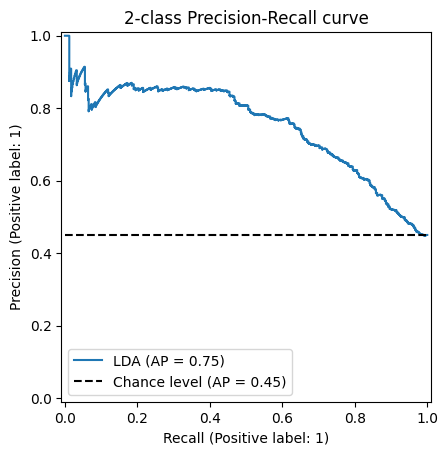

In [27]:
display = PrecisionRecallDisplay.from_estimator(
    lda_tune,   # trained model
    X_test,        # Test features
    y_test,        # True labels
    name="LDA",
    plot_chance_level=True,
)
display.ax_.set_title("2-class Precision-Recall curve")
plt.show()

### Confusion matrix

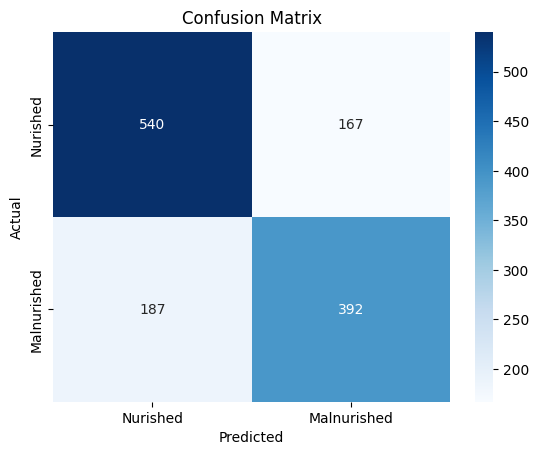

In [19]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Feature importance

In [21]:
# Get feature names
feature_names = X_train.columns

# Get LDA coefficients for the first discriminant axis
coefficients = lda_tune.coef_[0]  # For binary classification (or for each class pair)

# Create DataFrame for importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Importance (abs)': np.abs(coefficients)
})

# Sort by absolute importance
importance_df = importance_df.sort_values(by='Importance (abs)', ascending=False)

# Show top features
print(importance_df)


                   Feature  Coefficient  Importance (abs)
1             child_weight    -1.898810          1.898810
0                child_age     1.187271          1.187271
5                child_sex     0.417587          0.417587
7         health_insurance    -0.381035          0.381035
14            province_6.0     0.339572          0.339572
9             province_1.0    -0.261920          0.261920
4                     area    -0.152804          0.152804
11            province_3.0    -0.145146          0.145146
2   diarrhoea_last_2_weeks     0.139904          0.139904
15            province_7.0     0.128008          0.128008
10            province_2.0     0.117601          0.117601
12            province_4.0    -0.099635          0.099635
6         mother_education    -0.055881          0.055881
8             wealth_index    -0.030587          0.030587
3       fever_last_2_weeks    -0.022301          0.022301
13            province_5.0     0.011960          0.011960


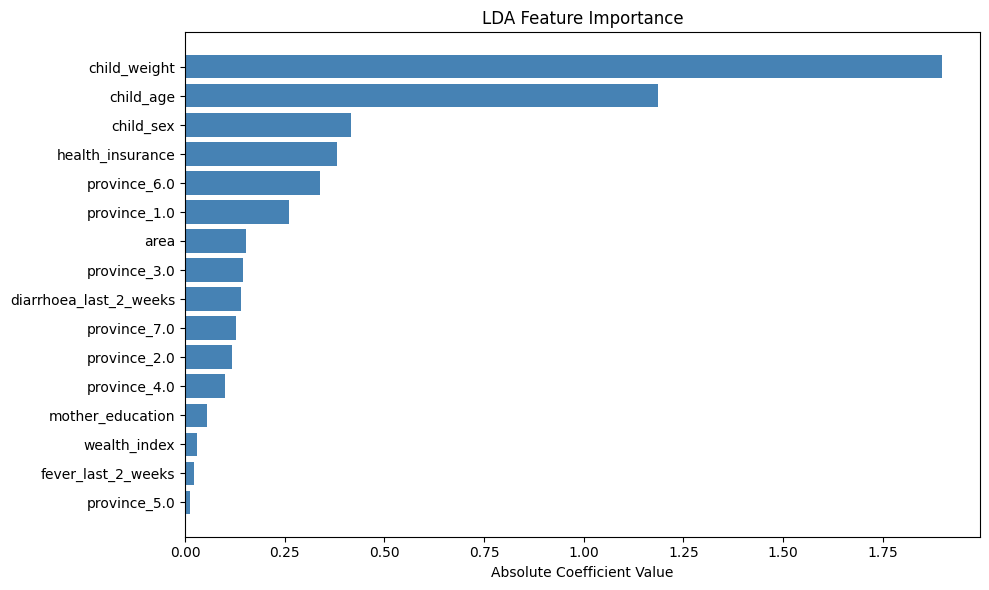

In [23]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance (abs)'], color='steelblue')
plt.xlabel("Absolute Coefficient Value")
plt.title("LDA Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Check separability of class 

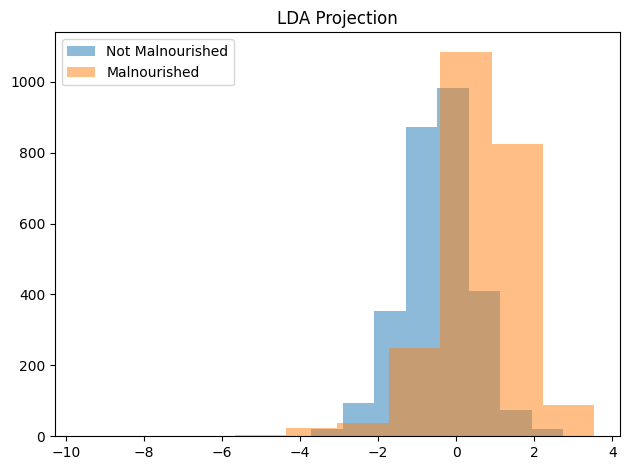

In [24]:
# Project training data
X_lda = lda_tune.transform(X_train)

# If 1 component
if X_lda.shape[1] == 1:
    plt.hist(X_lda[y_train == 0], alpha=0.5, label='Not Malnourished')
    plt.hist(X_lda[y_train == 1], alpha=0.5, label='Malnourished')
else:
    plt.scatter(X_lda[y_train == 0, 0], X_lda[y_train == 0, 1], label='Not Malnourished', alpha=0.6)
    plt.scatter(X_lda[y_train == 1, 0], X_lda[y_train == 1, 1], label='Malnourished', alpha=0.6)

plt.title("LDA Projection")
plt.legend()
plt.tight_layout()
plt.show()


### Additional

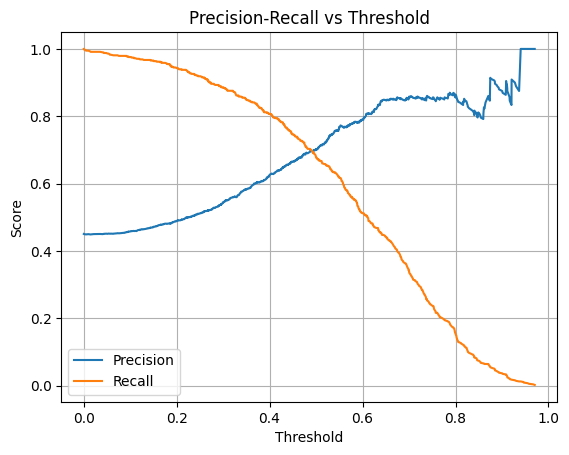

In [25]:
y_probas_tune = lda_tune.predict_proba(X_test)[:, 1]       #Probabilities for class 1
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [26]:
# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.79      0.60      0.69       707
           1       0.63      0.81      0.70       579

    accuracy                           0.70      1286
   macro avg       0.71      0.71      0.69      1286
weighted avg       0.72      0.70      0.69      1286


